# Motor d'explicabilitat del IDSS
## XGBoost + SHAP

Aquest notebook implementa el **motor d'explicabilitat** 

### Objectius del notebook
1. Carregar la base final preprocessada.
2. Entrenar el model **XGBoost** per predir `dropout`.
3. Avaluar el model amb mètriques i matriu de confusió.
4. Obtenir explicabilitat **global** amb SHAP.
5. Obtenir explicabilitat **local** per a casos individuals.
6. Exportar resultats útils per a l'informe i per a la resta del grup.


## Context dins l'arquitectura IDSS

Aquest notebook correspon al **motor d'explicabilitat**, és a dir, al component que rep **model + dades** i retorna **factors explicatius del risc**. La idea és que el sistema no només classifiqui l'estudiant, sinó que també expliqui **per què** ha estat classificat com a alumne de risc, per facilitar la presa de decisions del tutorat, professorat i orientació.

Treballarem en dos nivells:
- **Explicabilitat global**: quines variables tenen més pes en el risc d'abandonament.
- **Explicabilitat local**: per què un alumne concret surt amb risc alt o baix.


In [ ]:
# Instal·lació automàtica de dependències si falta alguna
import sys
import subprocess
import importlib.util

required_packages = ["xgboost", "shap", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"]

for pkg in required_packages:
    module_name = "sklearn" if pkg == "scikit-learn" else pkg
    if importlib.util.find_spec(module_name) is None:
        print(f"Instal·lant {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

print("Dependències revisades.")

Dependències revisades.


In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET_COL = "dropout"
DATA_PATH = "/Users/adriahernandez/Desktop/PAID/projecte/final/student_final.csv"
OUTPUT_DIR = Path("outputs_xgboost_shap")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [4]:
df = pd.read_csv(DATA_PATH)
print("Shape del dataset:", df.shape)
display(df.head())
display(df.dtypes)

Shape del dataset: (6607, 21)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,dropout
0,23,84,Low,High,0,7,73,Low,1,0,Low,Medium,Public,Positive,3,0,High School,Near,Male,67,0
1,19,64,Low,Medium,0,8,59,Low,1,2,Medium,Medium,Public,Negative,4,0,College,Moderate,Female,61,1
2,24,98,Medium,Medium,1,7,91,Medium,1,2,Medium,Medium,Public,Neutral,4,0,Postgraduate,Near,Male,74,0
3,29,89,Low,Medium,1,8,98,Medium,1,1,Medium,Medium,Public,Negative,4,0,High School,Moderate,Male,71,0
4,19,92,Medium,Medium,1,6,65,Medium,1,3,Medium,High,Public,Neutral,4,0,College,Near,Female,70,0


Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities     int64
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access                int64
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities          int64
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dropout                        int64
dtype: object

In [5]:
if TARGET_COL not in df.columns:
    raise ValueError(f"La variable objectiu '{TARGET_COL}' no existeix al dataset.")

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

if y.dtype == "object":
    y = y.map({
        "Yes": 1, "No": 0,
        "Dropout": 1, "No Dropout": 0,
        "True": 1, "False": 0
    })

y = y.astype(int)
display(y.value_counts().rename("count").to_frame())
display((y.value_counts(normalize=True).rename("proportion") * 100).round(2).to_frame())
print(list(X.columns))

,count
dropout,
0,5288
1,1319


,proportion
dropout,
0,80.04
1,19.96


['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


In [6]:
X_encoded = pd.get_dummies(X, drop_first=True)
feature_names = X_encoded.columns.tolist()
print("Shape de X després de get_dummies:", X_encoded.shape)
print(feature_names[:20])

Shape de X després de get_dummies: (6607, 28)
['Hours_Studied', 'Attendance', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Internet_Access', 'Tutoring_Sessions', 'Physical_Activity', 'Learning_Disabilities', 'Exam_Score', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Low', 'Access_to_Resources_Medium', 'Motivation_Level_Low', 'Motivation_Level_Medium', 'Family_Income_Low', 'Family_Income_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (5285, 28)
Test shape : (1322, 28)


In [8]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

metrics_df = pd.DataFrame([metrics]).round(4)
display(metrics_df)
print(classification_report(y_test, y_pred, zero_division=0))
metrics_df.to_csv(OUTPUT_DIR / "metrics_xgboost.csv", index=False)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.9796,0.9472,0.9508,0.949,0.9981


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1058
           1       0.95      0.95      0.95       264

    accuracy                           0.98      1322
   macro avg       0.97      0.97      0.97      1322
weighted avg       0.98      0.98      0.98      1322



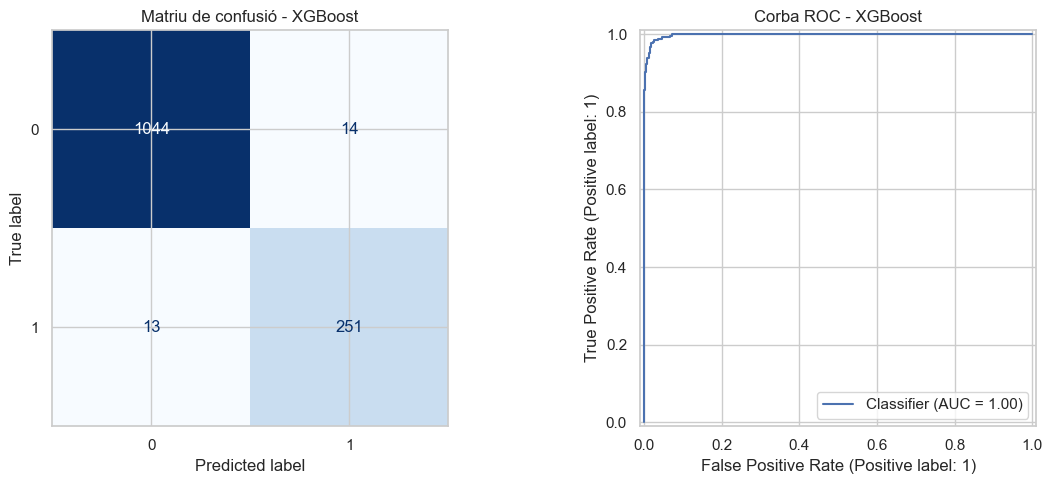

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriu de confusió - XGBoost")
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title("Corba ROC - XGBoost")
plt.tight_layout()
plt.show()

,Variable,Importance
9,Exam_Score,0.314433
14,Motivation_Level_Low,0.140735
15,Motivation_Level_Medium,0.108107
0,Hours_Studied,0.076490
1,Attendance,0.058262
4,Previous_Scores,0.044316
10,Parental_Involvement_Low,0.028659
12,Access_to_Resources_Low,0.021841
6,Tutoring_Sessions,0.020029
26,Distance_from_Home_Near,0.014697


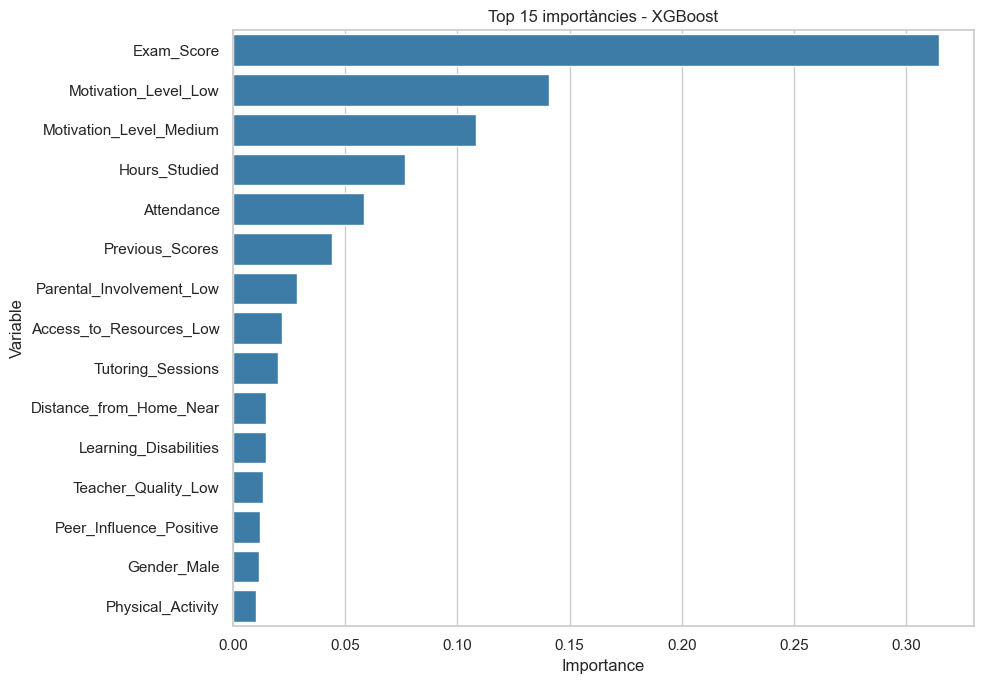

In [10]:
xgb_importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)
display(xgb_importance_df.head(20))
plt.figure(figsize=(10, 7))
sns.barplot(data=xgb_importance_df.head(15), x="Importance", y="Variable", color="#2c7fb8")
plt.title("Top 15 importàncies - XGBoost")
plt.tight_layout()
plt.show()
xgb_importance_df.to_csv(OUTPUT_DIR / "xgboost_feature_importance.csv", index=False)


## 8. SHAP: explicabilitat global i local

Farem servir SHAP per explicar el model XGBoost a dos nivells:
- **Global**: quines variables tenen més impacte mitjà sobre el risc.
- **Local**: per què un alumne concret ha estat classificat amb risc alt o baix.


In [11]:
# Aseguramos que SHAP reciba solo datos numéricos
X_train_shap = X_train.astype(float).copy()
X_test_shap = X_test.astype(float).copy()

BACKGROUND_SIZE = min(500, len(X_train_shap))
GLOBAL_EXPLAIN_SIZE = min(400, len(X_test_shap))

background = X_train_shap.sample(BACKGROUND_SIZE, random_state=RANDOM_STATE)
X_explain_global = X_test_shap.sample(GLOBAL_EXPLAIN_SIZE, random_state=RANDOM_STATE)

explainer = shap.Explainer(xgb_model, background)
shap_exp_global = explainer(X_explain_global)

print("Explicacions SHAP globals calculades correctament.")

Explicacions SHAP globals calculades correctament.


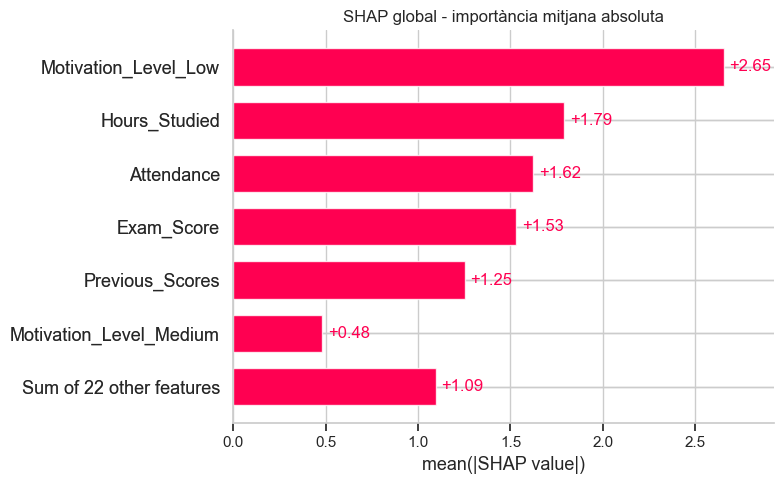

In [15]:
plt.figure(figsize=(10, 7))
shap.plots.bar(shap_exp_global, max_display=7, show=False)
plt.title("SHAP global - importància mitjana absoluta")
plt.tight_layout()
plt.show()

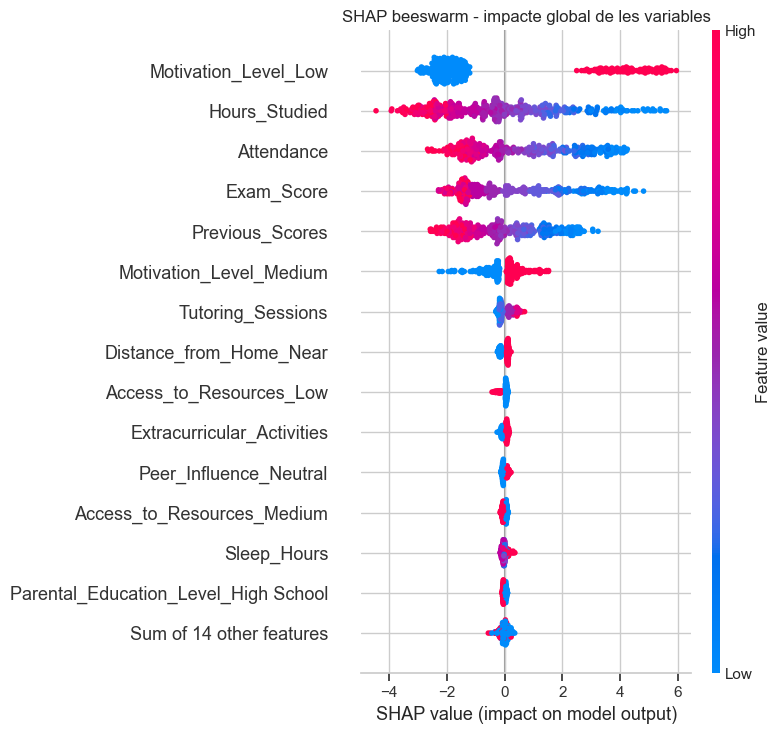

In [ ]:
plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_exp_global, max_display=15, show=False)
plt.title("SHAP beeswarm - impacte global de les variables")
plt.tight_layout()
plt.show()

In [14]:
mean_abs_shap = np.abs(shap_exp_global.values).mean(axis=0)
shap_global_df = pd.DataFrame({
    "Variable": X_explain_global.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values(by="MeanAbsSHAP", ascending=False)
display(shap_global_df.head(20))
shap_global_df.to_csv(OUTPUT_DIR / "shap_global_importance.csv", index=False)


,Variable,MeanAbsSHAP
14,Motivation_Level_Low,2.652965
0,Hours_Studied,1.792019
1,Attendance,1.621403
9,Exam_Score,1.530473
4,Previous_Scores,1.251481
15,Motivation_Level_Medium,0.480371
6,Tutoring_Sessions,0.214129
26,Distance_from_Home_Near,0.126262
12,Access_to_Resources_Low,0.087096
2,Extracurricular_Activities,0.086731


In [15]:
test_results = X_test.copy()
test_results["y_true"] = y_test.values
test_results["y_pred"] = y_pred
test_results["y_prob"] = y_prob

idx_high_risk = test_results.sort_values("y_prob", ascending=False).index[0]
idx_borderline = (test_results["y_prob"] - 0.5).abs().sort_values().index[0]
idx_low_risk = test_results.sort_values("y_prob", ascending=True).index[0]

selected_indices = [idx_high_risk, idx_borderline, idx_low_risk]
case_labels = ["Alt risc", "Borderline", "Baix risc"]

X_cases = X_test.loc[selected_indices]
case_exp = explainer(X_cases)

case_summary = pd.DataFrame({
    "Case_Label": case_labels,
    "Index": selected_indices,
    "y_true": y_test.loc[selected_indices].values,
    "y_pred": y_pred[[list(X_test.index).index(i) for i in selected_indices]],
    "y_prob": y_prob[[list(X_test.index).index(i) for i in selected_indices]]
}).round(4)
display(case_summary)
case_summary.to_csv(OUTPUT_DIR / "cases_selected_for_local_explanations.csv", index=False)


,Case_Label,Index,y_true,y_pred,y_prob
0,Alt risc,5719,1,1,0.9999
1,Borderline,2944,1,1,0.5067
2,Baix risc,6106,0,0,0.0000


In [ ]:
def prettify_feature_name(feature_name: str):
    return feature_name.replace("_", " ")

def build_local_contrib_table(explanation, x_row):
    local_df = pd.DataFrame({
        "Variable": x_row.index,
        "Value": x_row.values,
        "SHAP": explanation.values
    })
    local_df["AbsSHAP"] = local_df["SHAP"].abs()
    local_df["Variable"] = local_df["Variable"].apply(prettify_feature_name)
    return local_df.sort_values(by="AbsSHAP", ascending=False)

def plot_local_contributions(local_df, title, top_n=10):
    plot_df = local_df.head(top_n).copy().sort_values("SHAP")
    colors = ["#d73027" if v > 0 else "#1a9850" for v in plot_df["SHAP"]]
    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["Variable"], plot_df["SHAP"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("Contribució SHAP")
    plt.tight_layout()
    plt.show()

def generate_text_explanation(local_df, predicted_prob):
    top_positive = local_df.sort_values("SHAP", ascending=False).head(3)
    top_negative = local_df.sort_values("SHAP", ascending=True).head(2)

    pos_text = ", ".join([f"{row['Variable']} (valor={row['Value']})" for _, row in top_positive.iterrows() if row["SHAP"] > 0])
    neg_text = ", ".join([f"{row['Variable']} (valor={row['Value']})" for _, row in top_negative.iterrows() if row["SHAP"] < 0])

    if pos_text == "":
        pos_text = "cap factor destacat"
    if neg_text == "":
        neg_text = "cap factor protector destacat"

    risk_label = "alt risc" if predicted_prob >= 0.5 else "baix risc"

    return (
        f"L'alumne ha estat classificat com a {risk_label} "
        f"(probabilitat={predicted_prob:.3f}). "
        f"Els factors que més empenyen cap al risc són: {pos_text}. "
        f"Els principals factors que redueixen el risc són: {neg_text}."
    )

CAS: Alt risc | index original: 5719
Probabilitat de dropout: 0.9999


,Variable,Value,SHAP,AbsSHAP
9,Exam Score,57,4.173393,4.173393
14,Motivation Level Low,True,4.156534,4.156534
0,Hours Studied,9,4.012830,4.012830
1,Attendance,64,2.757261,2.757261
15,Motivation Level Medium,False,-0.738611,0.738611
4,Previous Scores,68,0.639292,0.639292
12,Access to Resources Low,True,-0.226109,0.226109
6,Tutoring Sessions,0,-0.181402,0.181402
26,Distance from Home Near,True,0.113583,0.113583
3,Sleep Hours,10,0.108785,0.108785


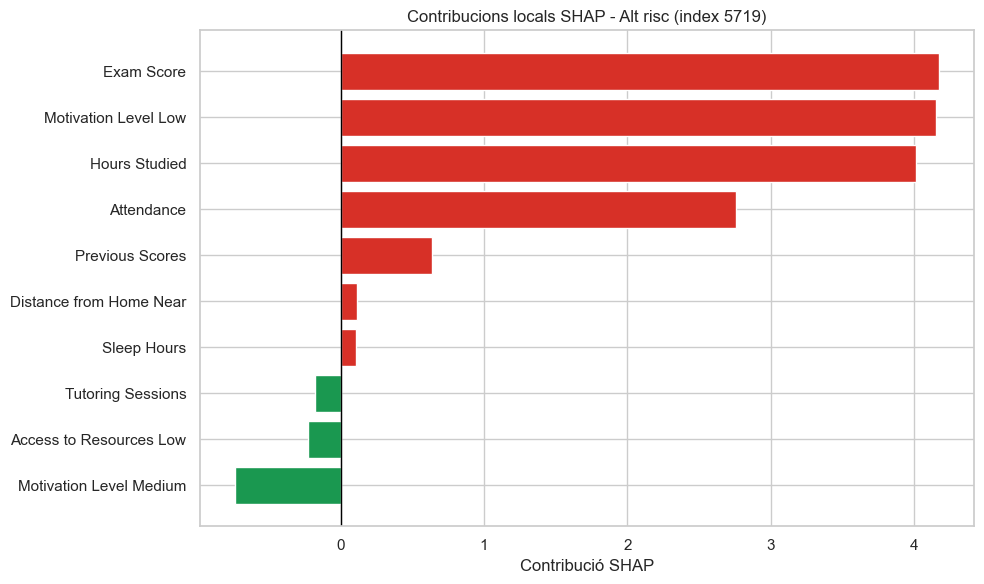

Explicació textual:
L'alumne ha estat classificat com a alt risc (probabilitat=1.000). Els factors que més empenyen cap al risc són: Exam Score (valor=57), Motivation Level Low (valor=True), Hours Studied (valor=9). Els principals factors que redueixen el risc són: Motivation Level Medium (valor=False), Access to Resources Low (valor=True).

CAS: Borderline | index original: 2944
Probabilitat de dropout: 0.5067


,Variable,Value,SHAP,AbsSHAP
9,Exam Score,62,3.746626,3.746626
1,Attendance,67,2.706632,2.706632
4,Previous Scores,53,2.529667,2.529667
14,Motivation Level Low,False,-2.134989,2.134989
0,Hours Studied,22,-1.539280,1.539280
15,Motivation Level Medium,True,0.890449,0.890449
6,Tutoring Sessions,0,-0.171185,0.171185
26,Distance from Home Near,False,-0.110008,0.110008
10,Parental Involvement Low,True,-0.101578,0.101578
17,Family Income Medium,True,-0.092795,0.092795


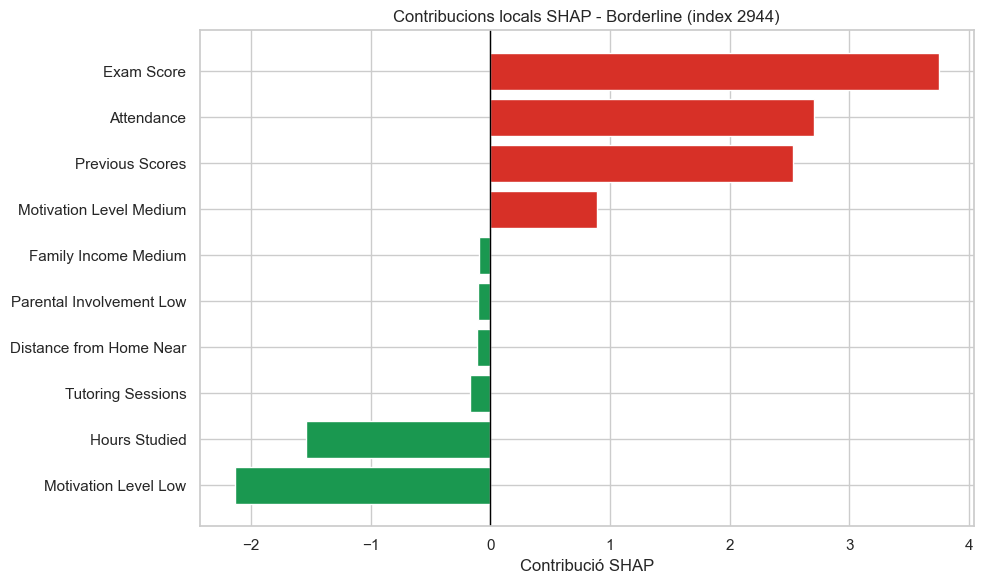

Explicació textual:
L'alumne ha estat classificat com a alt risc (probabilitat=0.507). Els factors que més empenyen cap al risc són: Exam Score (valor=62), Attendance (valor=67), Previous Scores (valor=53). Els principals factors que redueixen el risc són: Motivation Level Low (valor=False), Hours Studied (valor=22).

CAS: Baix risc | index original: 6106
Probabilitat de dropout: 0.0000


,Variable,Value,SHAP,AbsSHAP
0,Hours Studied,34,-2.322311,2.322311
4,Previous Scores,95,-1.370472,1.370472
9,Exam Score,70,-1.266188,1.266188
14,Motivation Level Low,False,-1.178083,1.178083
1,Attendance,91,-0.942322,0.942322
26,Distance from Home Near,False,-0.144701,0.144701
6,Tutoring Sessions,1,-0.134608,0.134608
3,Sleep Hours,7,-0.117345,0.117345
21,Peer Influence Neutral,False,-0.106796,0.106796
15,Motivation Level Medium,True,0.102094,0.102094


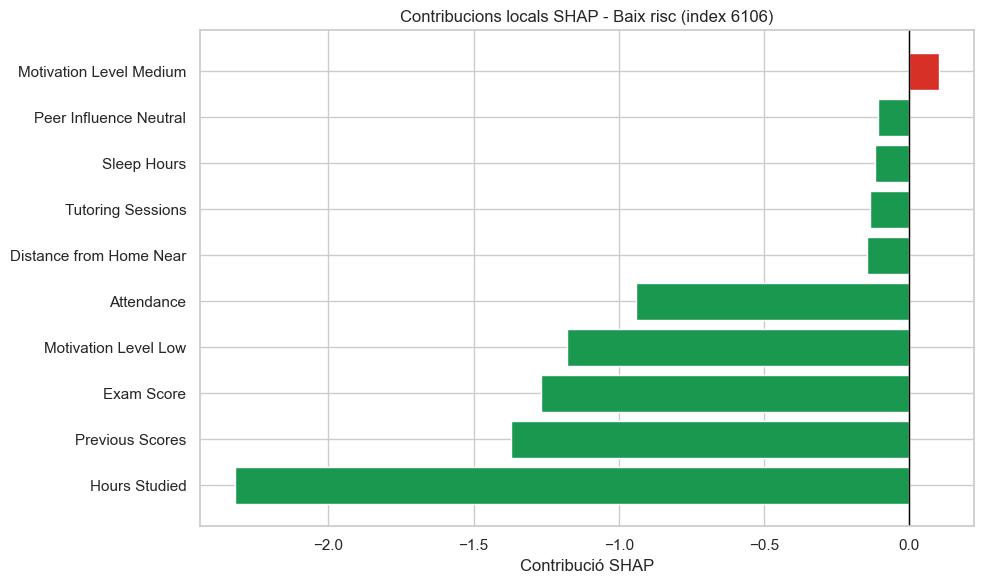

Explicació textual:
L'alumne ha estat classificat com a baix risc (probabilitat=0.000). Els factors que més empenyen cap al risc són: Motivation Level Medium (valor=True), Parental Education Level High School (valor=False), Access to Resources Low (valor=False). Els principals factors que redueixen el risc són: Hours Studied (valor=34), Previous Scores (valor=95).



In [ ]:
local_texts = []

for i, case_label in enumerate(case_labels):
    idx = selected_indices[i]
    x_row = X_cases.iloc[i]
    explanation = case_exp[i]
    pred_prob = case_summary.iloc[i]["y_prob"]

    local_df = build_local_contrib_table(explanation, x_row)
    print("=" * 90)
    print(f"CAS: {case_label} | index original: {idx}")
    print(f"Probabilitat de dropout: {pred_prob:.4f}")
    display(local_df.head(15))

    plot_local_contributions(local_df, f"Contribucions locals SHAP - {case_label} (index {idx})", top_n=10)

    text_expl = generate_text_explanation(local_df, pred_prob)
    print("Explicació textual:")
    print(text_expl)
    print()

    local_df.to_csv(OUTPUT_DIR / f"local_shap_case_{case_label.lower().replace(' ', '_')}_{idx}.csv", index=False)
    local_texts.append({
        "Case_Label": case_label,
        "Index": idx,
        "Predicted_Probability": pred_prob,
        "Text_Explanation": text_expl
    })

pd.DataFrame(local_texts).to_csv(OUTPUT_DIR / "local_text_explanations.csv", index=False)

## 12. Lectura final dels resultats

La idea és que aquest motor d'explicabilitat permeti:
- veure **quines variables dominen globalment** la predicció del risc,
- validar si això és coherent amb l'EDA i amb l'anàlisi supervisada,
- i, sobretot, donar una **explicació individual** per a cada alumne.

A nivell pràctic, aquest mòdul és el que permet passar de:

> "aquest alumne està en risc"

a una frase útil per a intervenció, com ara:

> "aquest alumne presenta risc principalment per motivació baixa, baixa assistència i poques hores d'estudi".


In [ ]:
print("Fitxers generats a:", OUTPUT_DIR.resolve())
print(sorted([p.name for p in OUTPUT_DIR.iterdir()]))

Fitxers generats a: /Users/adriahernandez/Desktop/PAID/projecte/final/outputs_xgboost_shap
['.DS_Store', '1.png', '2.png', '3.png', '4.png', '5.png', '6.png', '7.png', 'cases_selected_for_local_explanations.csv', 'local_shap_case_alt_risc_4425.csv', 'local_shap_case_alt_risc_5719.csv', 'local_shap_case_baix_risc_6106.csv', 'local_shap_case_baix_risc_6327.csv', 'local_shap_case_borderline_2397.csv', 'local_shap_case_borderline_2944.csv', 'local_text_explanations.csv', 'metrics_xgboost.csv', 'resultados.txt', 'shap_global_importance.csv', 'xgboost_feature_importance.csv']
